In [1]:
# Importing Required Libraries  
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sns

# Loading the Dataset 
df=pd.read_csv("Project_Resources/train.csv",index_col="Row_ID")

# Data Cleanup
df=df.convert_dtypes()
df["Postal_Code"]=df["Postal_Code"].fillna(0)
df["Postal_Code"]=df["Postal_Code"].astype(int)
l=["Order_Date","Ship_Date"]
for i in l:
    df[i]=pd.to_datetime(df[i],format="%d-%m-%Y")

# Recurring customer data
This analysis will try to find:
1. The Repeat Customer  Rate (RCR) of different states in the US and
2. Also different category of products.

In [ ]:
df_annual=df[df["Order_Date"].dt.year==2017]
df_pivot=df_annual.pivot_table(index="Customer_ID", columns="Sub-Category", values="Customer_Name", aggfunc="count", fill_value=0)
df_pivot.loc["Total"]=df_pivot.sum()
df_pivot=df_pivot[df_pivot.loc["Total"].sort_values(ascending=False).index]
df_pivot.reset_index(inplace=True)
df_req=df_pivot.iloc[:, :6]

`df_pivot.loc["Total"]=df_pivot.sum()` this will create a total row which is used in arranging the data. 

In [3]:
def rep_cus(k, d_frame):
    num=0
    for i in d_frame:
        if i==k:
            for j in range(0,len(d_frame)-1):
                if int(d_frame[i][j])>1:
                    num=num+1
    return num
l=[[i, rep_cus(i,df_req), rep_cus(i,df_req)/len(df_req)*100] for i in df_req if i!="Customer_ID"]

`rep_cus():` is a user-defined function created to reuse lines of codes written under it.

In [15]:
df_plot=pd.DataFrame(l, columns=["Sub-Category", "No. of repeat customer", "Repeat Rate"])
df_plot=df_plot.sort_values(by="Repeat Rate", ascending=False)

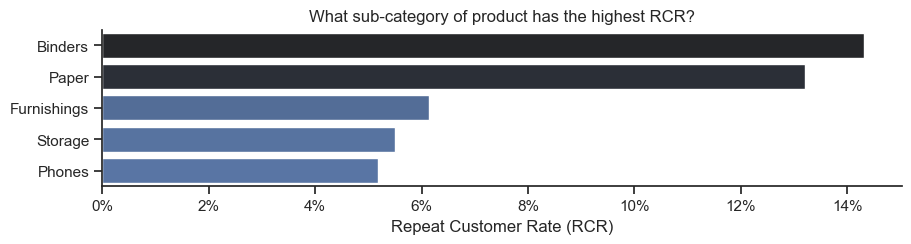

In [17]:
sns.barplot(data=df_plot, x="Repeat Rate", y="Sub-Category", hue="Repeat Rate",palette="dark:b_r", legend=False)
sns.set_theme(style="ticks")
mp.title("What sub-category of product has the highest RCR?")
fig=mp.gcf()
ax=mp.gca()
mp.xlabel("Repeat Customer Rate (RCR)")
mp.ylabel("")
ax.xaxis.set_major_formatter(mp.FuncFormatter(lambda x, pos: f"{int(x)}%"))
sns.despine()
mp.tight_layout()
fig.set_size_inches(10,2)

In [6]:
df_piv=df_annual.pivot_table(index="Customer_ID", columns="State", values="Customer_Name", aggfunc="count", fill_value=0)

In [7]:
df_piv.loc["Total"]=df_piv.sum()
df_piv=df_piv[df_piv.loc["Total"].sort_values(ascending=False).index]
df_piv=df_piv.drop("Total")
df_piv

State,California,New York,Texas,Pennsylvania,Ohio,Washington,Illinois,Florida,North Carolina,Michigan,...,Utah,Kansas,New Hampshire,District of Columbia,Louisiana,Idaho,New Mexico,Vermont,Maine,Wyoming
Customer_ID,,,,,,,,,,,,,,,,,,,,,
AA-10315,0,0,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AA-10375,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AA-10480,0,0,0,0,0,0,0,0,0,5,...,0,0,0,0,0,0,0,0,0,0
AA-10645,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-10015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WB-21850,11,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
XP-21865,7,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
YC-21895,1,0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df_piv.reset_index(inplace=True)
df_required=df_piv.iloc[:, :6]
df_required

State,Customer_ID,California,New York,Texas,Pennsylvania,Ohio
0,AA-10315,0,0,4,0,0
1,AA-10375,0,0,0,0,0
2,AA-10480,0,0,0,0,0
3,AA-10645,4,0,0,0,0
4,AB-10015,0,0,0,0,0
...,...,...,...,...,...,...
630,WB-21850,11,3,0,0,0
631,XP-21865,7,0,0,0,0
632,YC-21895,1,0,2,0,0
633,ZC-21910,0,0,3,0,0


In [9]:
j=[[i, rep_cus(i, df_required), rep_cus(i, df_required)/len(df_required)*100] for i in df_required if i!="Customer_ID"]
df_plot_new=pd.DataFrame(j, columns=["State", "No. of repeating Customer", "Repeat Rate"])
df_plot_new

,State,No. of repeating Customer,Repeat Rate
0,California,128,20.157480
1,New York,74,11.653543
2,Texas,65,10.236220
3,Pennsylvania,32,5.039370
4,Ohio,29,4.566929


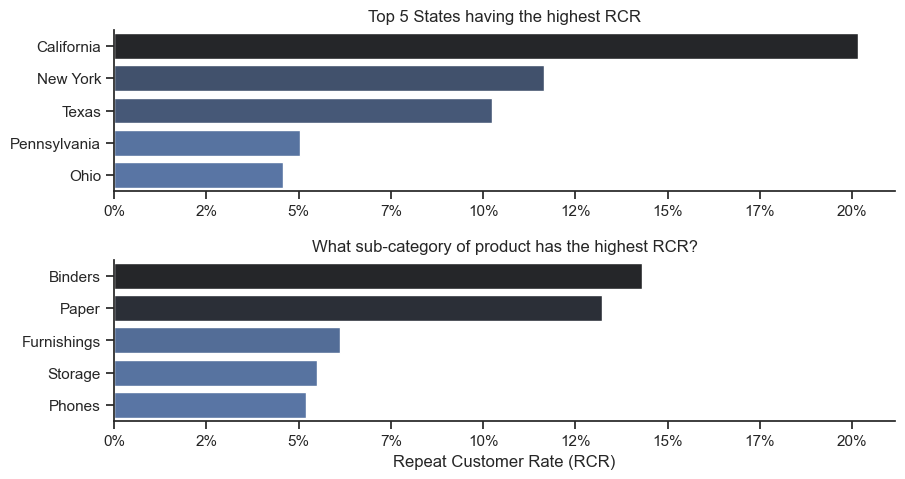

In [18]:
fig,ax= mp.subplots(2,1)
sns.set_theme(style="ticks")

sns.barplot(data=df_plot_new, x="Repeat Rate", y="State", hue="Repeat Rate",palette="dark:b_r", legend=False, ax=ax[0])
ax[0].set_title("Top 5 States having the highest RCR")
ax[0].set_ylabel("")
ax[0].set_xlabel("")
ax[0].xaxis.set_major_formatter(mp.FuncFormatter(lambda x, pos: f"{int(x)}%"))


sns.barplot(data=df_plot, x="Repeat Rate", y="Sub-Category", hue="Repeat Rate",palette="dark:b_r", legend=False, ax=ax[1])
ax[1].set_title("What sub-category of product has the highest RCR?")
ax[1].set_ylabel("")
ax[1].set_xlabel("Repeat Customer Rate (RCR)")
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(mp.FuncFormatter(lambda x, pos: f"{int(x)}%"))

sns.despine()
mp.tight_layout()
fig.set_size_inches(10,5) 